In [2]:
# Celda 1 - Todo junto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import shap

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Rutas y cargar
GOLD_PATH = Path('../data/gold')
ML_PATH = Path('../data/processed/04_train_test')
OUTPUT_PATH = Path('../data/shap')
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print('[1] Cargando datos...')
df = pd.read_parquet(GOLD_PATH / 'gold_barrios_completo_limpio.parquet')

with open(ML_PATH / 'feature_names.json', 'r') as f:
    feature_names = json.load(f)

with open(ML_PATH / 'best_model_SVM_RBF.pkl', 'rb') as f:
    modelo = pickle.load(f)

with open(ML_PATH / 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

X = df[feature_names]
y = df['gentrificara']

print(f'✅ Datos: {X.shape}')
print(f'✅ Features: {len(feature_names)}')
print(f'✅ Target: {y.value_counts().to_dict()}')

# SHAP Explainer
print('\n[2] Creando SHAP Explainer...')
explainer = shap.KernelExplainer(modelo.predict_proba, X.iloc[:50])
print('✅ Explainer creado')

print('\n[3] Calculando SHAP values (espera 3-5 minutos)...')
shap_values = explainer.shap_values(X)
shap_values_gentrif = shap_values[:, :, 1]
print(f'✅ SHAP values: {shap_values.shape}')

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'shap_importance': np.abs(shap_values_gentrif).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

print('\n[TOP 10 FEATURES]\n')
print(feature_importance.head(10).to_string(index=False))

[1] Cargando datos...
✅ Datos: (130, 21)
✅ Features: 21
✅ Target: {0: 98, 1: 32}

[2] Creando SHAP Explainer...
✅ Explainer creado

[3] Calculando SHAP values (espera 3-5 minutos)...


100%|██████████| 130/130 [00:55<00:00,  2.34it/s]

✅ SHAP values: (130, 21, 2)

[TOP 10 FEATURES]

                    feature  shap_importance
              tendencia_54m         0.055779
         renta_mediana_2023         0.052769
         variabilidad_bares         0.051011
     cambio_renta_2022_2026         0.043598
           renta_media_2023         0.037172
           distancia_centro         0.036199
             n_bares_202606         0.033460
   pct_poblacion_renta_baja         0.028881
             n_bares_202206         0.025964
velocidad_crecimiento_anual         0.023024


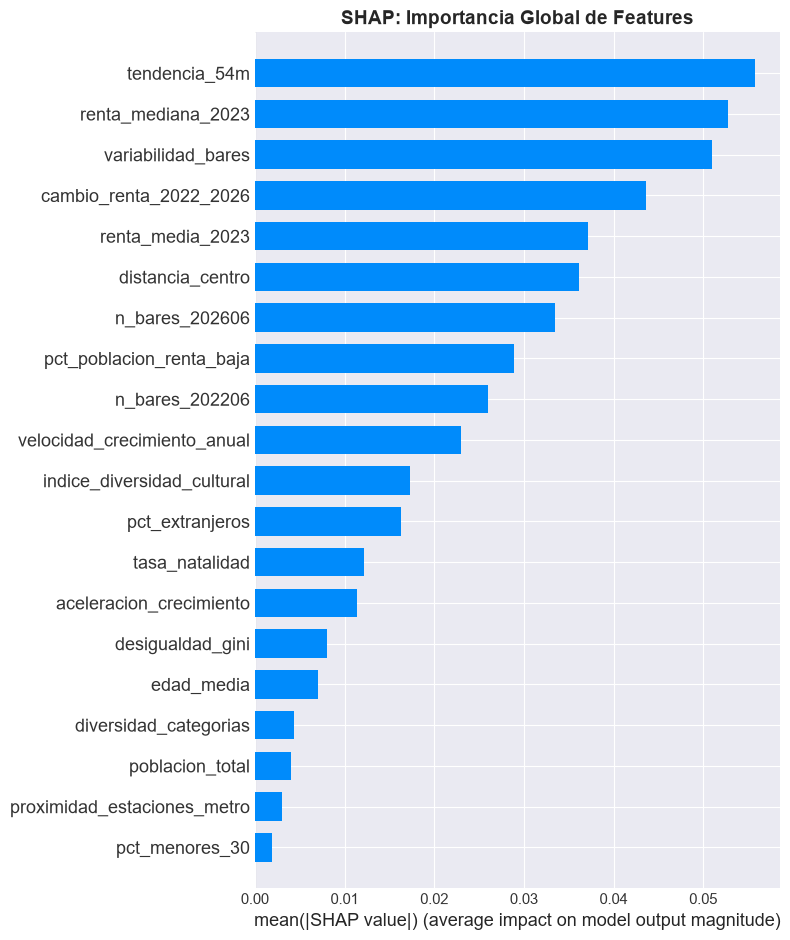

In [3]:
# Celda 2 - Summary Plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values_gentrif, X, plot_type='bar', show=False)
plt.title('SHAP: Importancia Global de Features', fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig(OUTPUT_PATH / '01_shap_summary_bar.png', dpi=300, bbox_inches='tight')
plt.show()

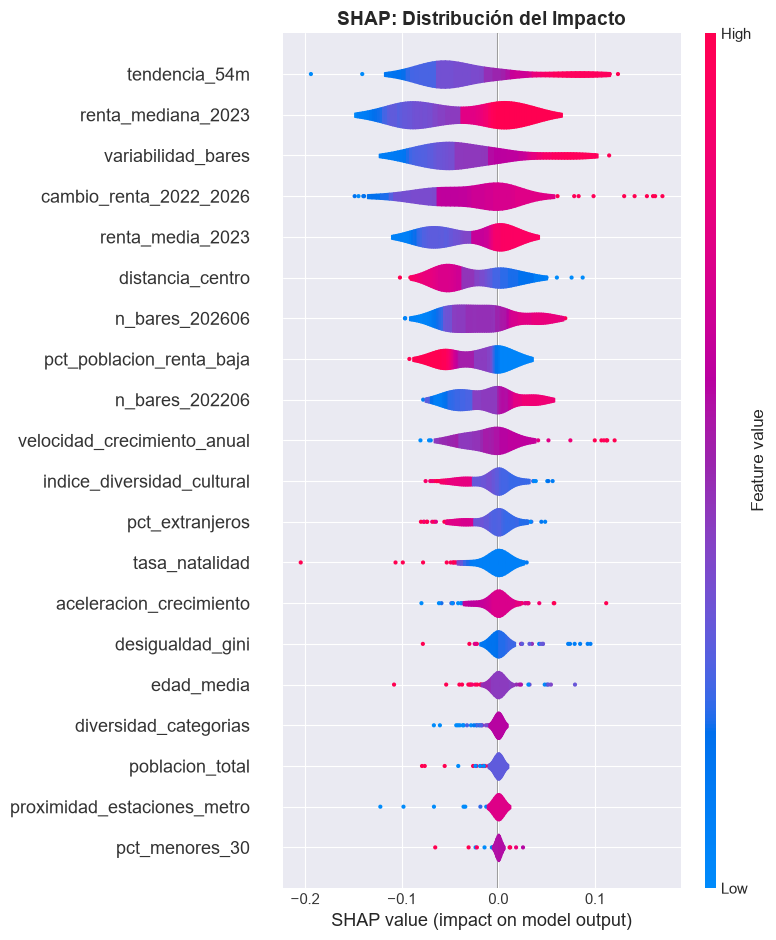

In [4]:
# Celda 3 - Violin Plot
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(shap_values_gentrif, X, plot_type='violin', show=False)
plt.title('SHAP: Distribución del Impacto', fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig(OUTPUT_PATH / '02_shap_summary_violin.png', dpi=300, bbox_inches='tight')
plt.show()

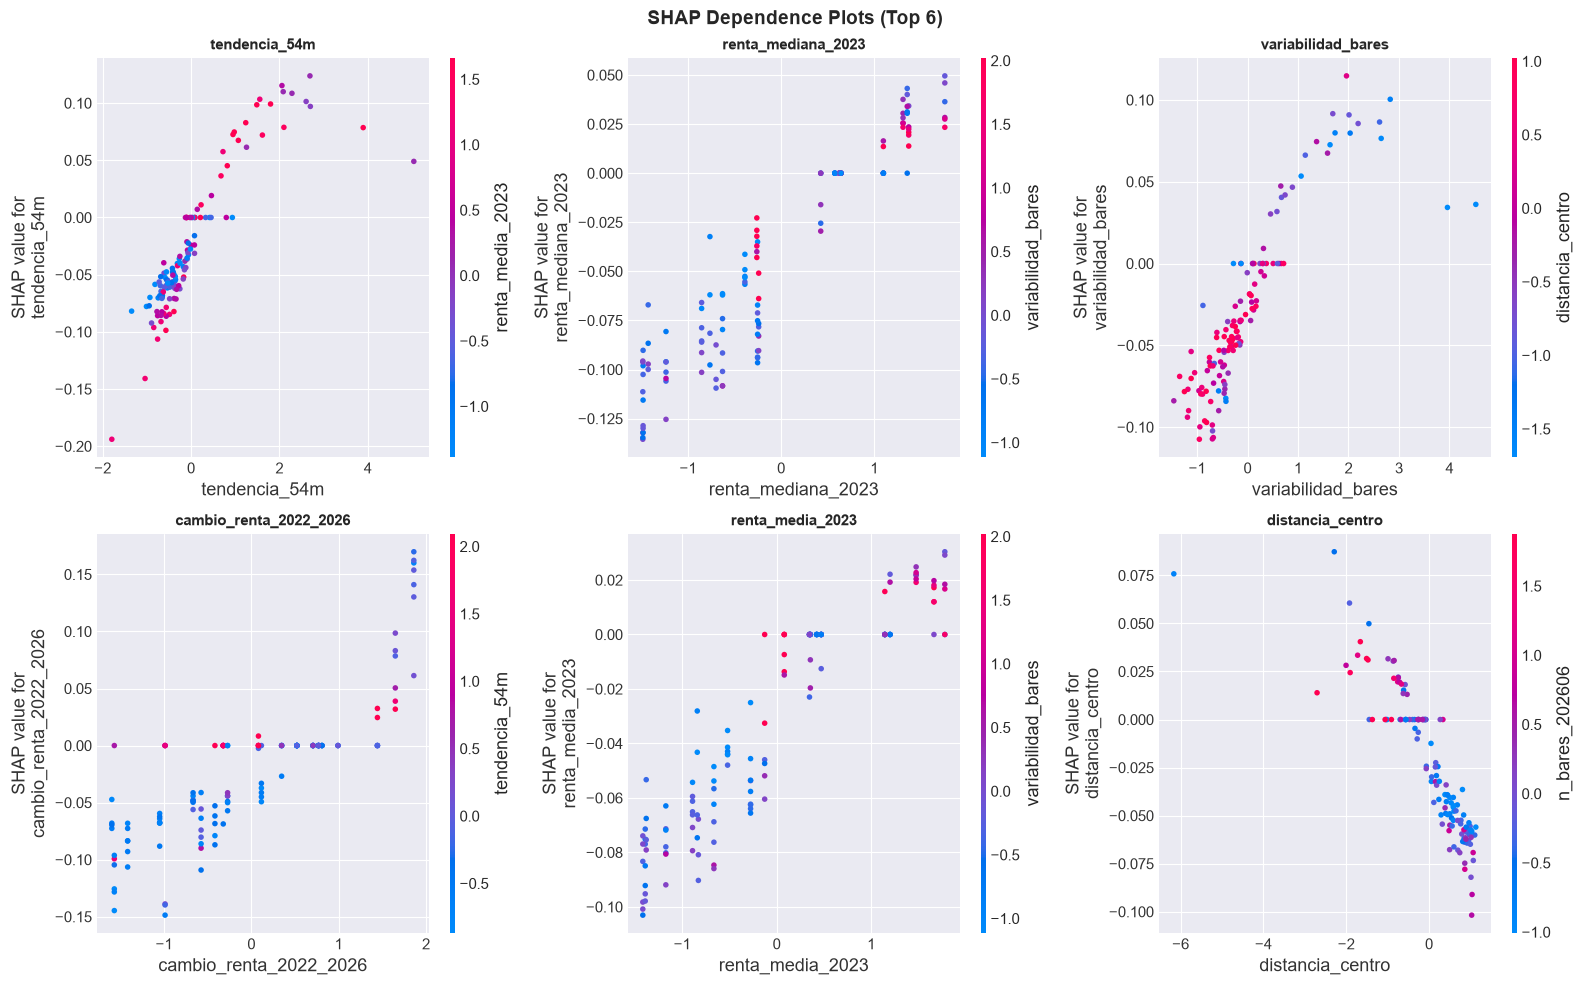

In [5]:
# Celda 4 - Dependence Plots
top_6_features = feature_importance.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_6_features):
    feature_idx = feature_names.index(feature)
    ax = axes[idx]
    shap.dependence_plot(feature_idx, shap_values_gentrif, X, 
                        feature_names=feature_names, ax=ax, show=False)
    ax.set_title(f'{feature}', fontsize=11, fontweight='bold')

fig.suptitle('SHAP Dependence Plots (Top 6)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / '03_shap_dependence_top6.png', dpi=300, bbox_inches='tight')
plt.show()

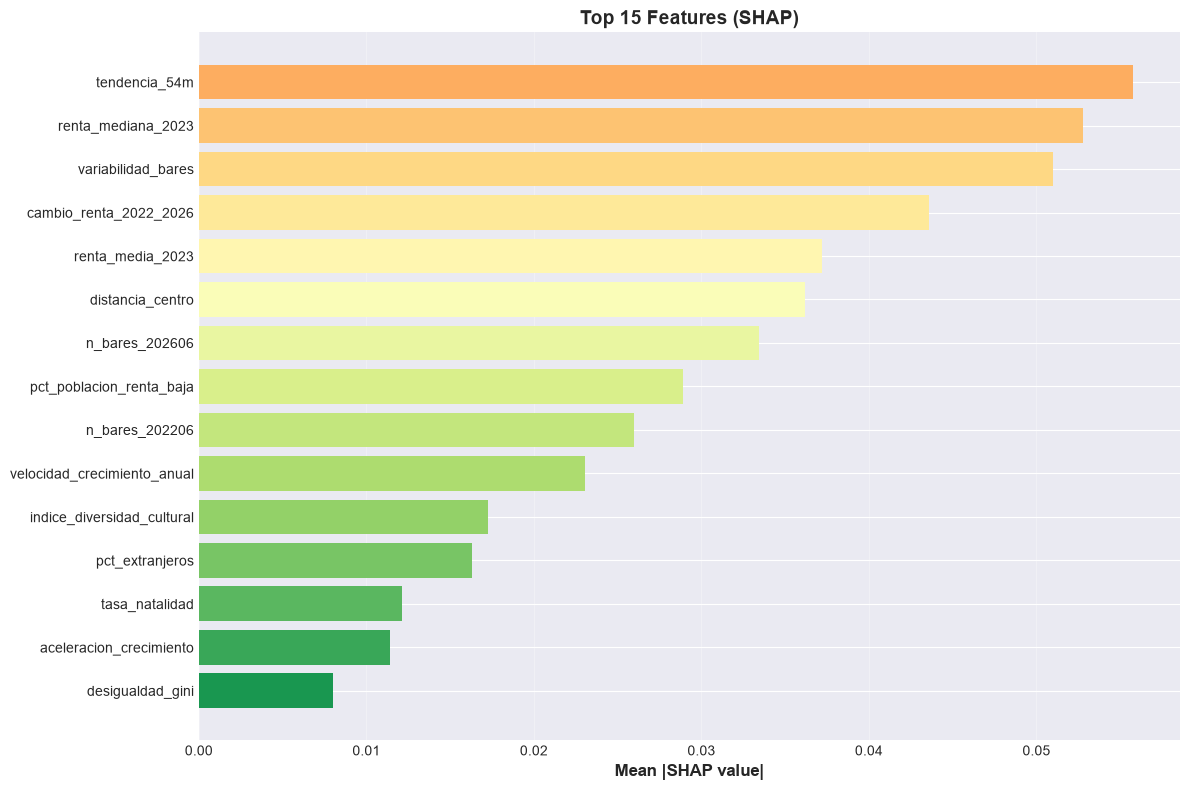

In [6]:
# Celda 5 - Feature Importance Ranking
fig, ax = plt.subplots(figsize=(12, 8))
top_15 = feature_importance.head(15)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_15)))

ax.barh(range(len(top_15)), top_15['shap_importance'].values, color=colors)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['feature'].values)
ax.set_xlabel('Mean |SHAP value|', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Features (SHAP)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_PATH / '04_feature_importance_ranking.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Celda 6 - Interpretación
print('='*80)
print('¿QUÉ PREDICE GENTRIFICACIÓN?')
print('='*80)

top_5 = feature_importance.head(5)
for idx, (_, row) in enumerate(top_5.iterrows(), 1):
    feature = row['feature']
    importance = row['shap_importance']
    corr = df[feature].corr(y)
    print(f'{idx}. {feature}: SHAP={importance:.4f}, Corr={corr:.3f}')

print('''
PATRÓN: Gentrificación = DINÁMISMO HOSTELERO + RENTA ALTA + CAMBIO

1. tendencia_54m: Crecimiento sostenido en hostelería
2. variabilidad_bares: Dinamismo en oferta
3. renta_media_2023: Nivel económico
4. renta_mediana_2023: Desigualdad económica
5. desigualdad_gini: Inequidad
''')

# Guardar CSV
feature_importance.to_csv(OUTPUT_PATH / 'feature_importance_shap.csv', index=False)
print(f'\n✅ ANÁLISIS SHAP COMPLETADO')
print(f'✅ Guardados en: {OUTPUT_PATH}')

¿QUÉ PREDICE GENTRIFICACIÓN?
1. tendencia_54m: SHAP=0.0558, Corr=0.631
2. renta_mediana_2023: SHAP=0.0528, Corr=0.466
3. variabilidad_bares: SHAP=0.0510, Corr=0.556
4. cambio_renta_2022_2026: SHAP=0.0436, Corr=0.322
5. renta_media_2023: SHAP=0.0372, Corr=0.489

PATRÓN: Gentrificación = DINÁMISMO HOSTELERO + RENTA ALTA + CAMBIO

1. tendencia_54m: Crecimiento sostenido en hostelería
2. variabilidad_bares: Dinamismo en oferta
3. renta_media_2023: Nivel económico
4. renta_mediana_2023: Desigualdad económica
5. desigualdad_gini: Inequidad


✅ ANÁLISIS SHAP COMPLETADO
✅ Guardados en: ..\data\shap
